In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

df = pd.read_csv("../data/KDDTrain+.txt", names=columns)
df["binary_label"] = df["label"].apply(lambda x: "normal" if x == "normal" else "attack")

Matplotlib is building the font cache; this may take a moment.


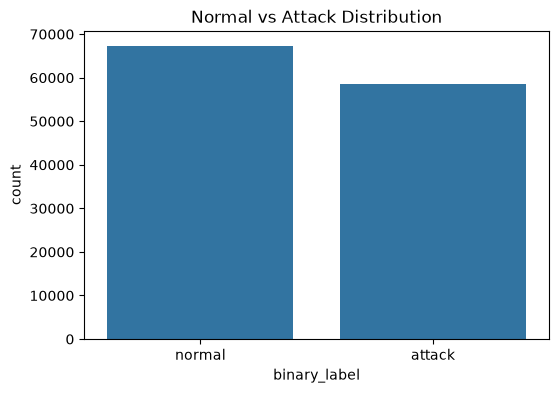

In [2]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="binary_label")
plt.title("Normal vs Attack Distribution")
plt.show()

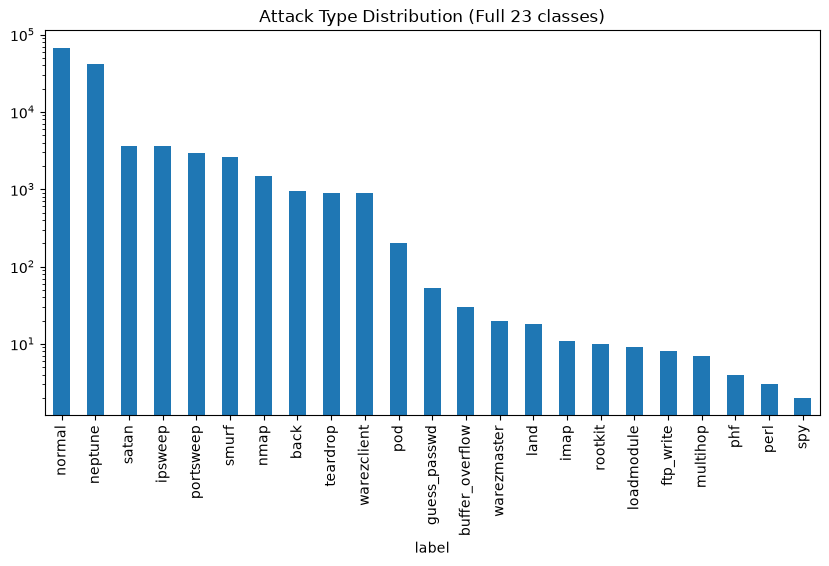

In [3]:
plt.figure(figsize=(10,5))
df["label"].value_counts().plot(kind="bar")
plt.title("Attack Type Distribution (Full 23 classes)")
plt.yscale("log")  # log scale because normal/neptune dwarf the rest
plt.show()

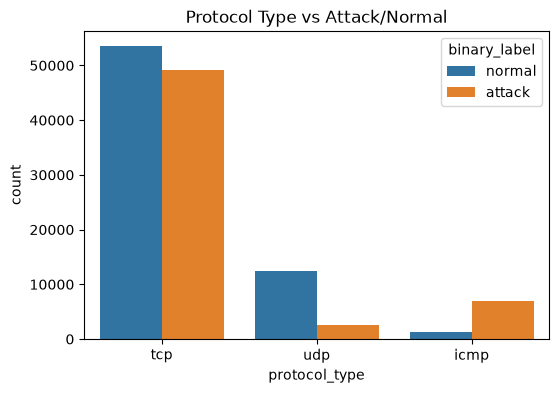

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="protocol_type", hue="binary_label")
plt.title("Protocol Type vs Attack/Normal")
plt.show()

In [5]:
df[["duration", "src_bytes", "dst_bytes"]].describe()

,duration,src_bytes,dst_bytes
count,125973.00000,1.259730e+05,1.259730e+05
mean,287.14465,4.556674e+04,1.977911e+04
std,2604.51531,5.870331e+06,4.021269e+06
min,0.00000,0.000000e+00,0.000000e+00
25%,0.00000,0.000000e+00,0.000000e+00
50%,0.00000,4.400000e+01,0.000000e+00
75%,0.00000,2.760000e+02,5.160000e+02
max,42908.00000,1.379964e+09,1.309937e+09


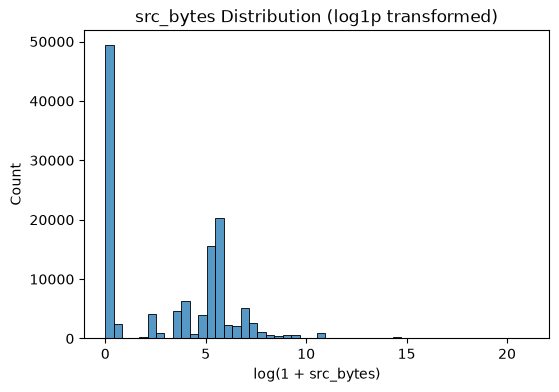

In [7]:
import numpy as np

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df["src_bytes"]), bins=50)
plt.title("src_bytes Distribution (log1p transformed)")
plt.xlabel("log(1 + src_bytes)")
plt.show()